Mahan Madani - 830504035

## Table of Contents

- [Import Libraries and Custom Classes](#import-libraries-and-custom-classes)
- [Create Datasets and Dataloaders](#create-datasets-and-dataloaders)
- [Load and Train Model](#load-and-train-model)
- [Loss and Metric Plots](#loss-and-metric-plots)

## Import Libraries and Custom Classes

In [1]:
import torch
from torch.utils.data import DataLoader
from transformers import T5TokenizerFast, CLIPImageProcessorFast

import matplotlib.pyplot as plt
import json

In [2]:
from Modules.config import (TRAIN_IMAGE_DIR,
                            TEST_IMAGE_DIR,
                            FAISS_IMAGE_PATH,
                            TRAIN_METADATA_PATH,
                            TEST_METADATA_PATH,
                            CLIP_MODEL_NAME,
                            T5_MODEL_NAME)

from Modules.FusionVLM import create_default_FusionVLM, load_default_FusionVLM
from Modules.retrieval_module import Retriever
from Modules.datasets import Flickr30kVLMDataset, VLMDataCollator
from Modules.utils import print_model_param_stats, add_dict, display_image
from Modules.metrics import setup_nltk
from Modules.train_VLM import train_and_evaluate_model

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Create Datasets and Dataloaders

In [4]:
CLIP_processor = CLIPImageProcessorFast.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
T5_tokenizer = T5TokenizerFast.from_pretrained(T5_MODEL_NAME, local_files_only=True)
collator_T5 = VLMDataCollator(CLIP_processor, T5_tokenizer, device=DEVICE)
collator = collator_T5

In [5]:
train_retriever = Retriever(metadata_path=TRAIN_METADATA_PATH, faiss_path=FAISS_IMAGE_PATH)
test_retriever = Retriever(metadata_path=TEST_METADATA_PATH, faiss_path=FAISS_IMAGE_PATH)

train_dataset = Flickr30kVLMDataset(image_dir=TRAIN_IMAGE_DIR, 
                           ref_image_dir=TRAIN_IMAGE_DIR,
                        #    metadata_path=TRAIN_METADATA_PATH,
                           retriever=train_retriever)

test_dataset = Flickr30kVLMDataset(image_dir=TEST_IMAGE_DIR, 
                           ref_image_dir=TRAIN_IMAGE_DIR,
                        #    metadata_path=TEST_METADATA_PATH,
                           retriever=test_retriever,
                           reference_retriever=train_retriever)

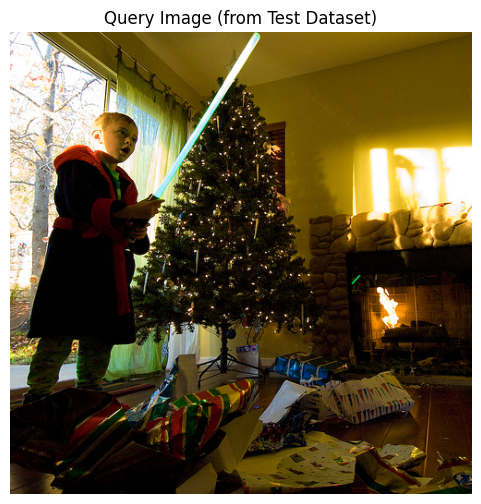

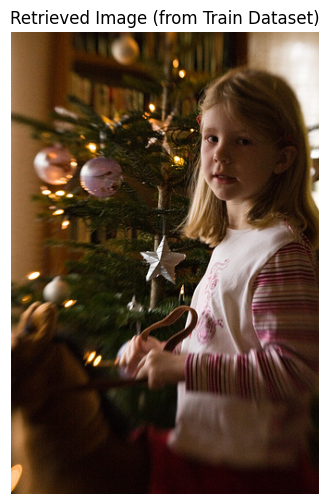

context - Similar images are described as: 
 A small boy  toys on the floor and a Christmas tree behind him  holds a bright yellow  plastic shovel pointed at the camera . a child next to a Christmas tree playing with brooms A little boy is playing with a yellow shovel in front of a Christmas tree .
target captions - ['A picture of Young boy holding a light saber in front of a Christmas tree with wrapping paper littering the floor .', 'A picture of Boy indoors by Christmas tree  playing with green  light-up sword toy .', 'A picture of A boy holds a light saber in front of a Christmas tree .', 'A picture of A boy receives a light saber for Christmas .', 'A picture of A boy looks at a new toy during christmas']


In [6]:
sample = test_dataset[121]
display_image(sample['query_image'], title='Query Image (from Test Dataset)')
display_image(sample['retrieved_image'], title='Retrieved Image (from Train Dataset)')
print(f'context - {sample['context']}')
print(f'target captions - {sample['all_captions']}')

In [6]:
BATCH_SIZE = 16
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collator)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collator)

## Load and Train Model

In [7]:
model = create_default_FusionVLM(use_local_files=True).to(DEVICE)

In [10]:
print_model_param_stats(model)

Module                                          Total    Trainable       Frozen
--------------------------------------------------------------------------------
vision_encoder                             87,456,000            0   87,456,000
text_encoder                              109,628,544            0  109,628,544
vision_proj                                   590,592      590,592            0
text_proj                                     590,592      590,592            0
fusion_blocks                              56,724,480   56,724,480            0
post_fusion_ln                                  1,536        1,536            0
fusion_proj                                   590,592      590,592            0
text_decoder                              254,655,744   31,752,192  222,903,552
--------------------------------------------------------------------------------
TOTAL                                     510,238,080   90,249,984  419,988,096


In [9]:
NUM_EPOCHS = 10
full_history = {}
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=0.01
)

setup_nltk()

In [12]:
history = train_and_evaluate_model(model, train_loader, optimizer, NUM_EPOCHS, test_loader, T5_tokenizer)
add_dict(full_history, history)

Epoch 1: 100%|██████████| 1924/1924 [15:34<00:00,  2.06it/s, loss=2.42]


Avg Loss: 2.41313335
Val Loss: 2.10248758
BLEU-1: 0.6174
BLEU-2: 0.4362
BLEU-3: 0.3161
BLEU-4: 0.2285
METEOR: 0.4379
ROUGE-L: 0.4743
CIDEr: 0.1980


Epoch 2: 100%|██████████| 1924/1924 [15:23<00:00,  2.08it/s, loss=1.8] 


Avg Loss: 2.14592628
Val Loss: 2.08570576
BLEU-1: 0.5628
BLEU-2: 0.3792
BLEU-3: 0.2415
BLEU-4: 0.1553
METEOR: 0.4043
ROUGE-L: 0.4329
CIDEr: 0.1570


Epoch 3: 100%|██████████| 1924/1924 [15:26<00:00,  2.08it/s, loss=2.13]


...

Avg Loss: 1.89291704
Val Loss: 1.98327051
BLEU-1: 0.6202
BLEU-2: 0.4053
BLEU-3: 0.2357
BLEU-4: 0.1409
METEOR: 0.3870
ROUGE-L: 0.4404
CIDEr: 0.1972


Epoch 9: 100%|██████████| 1924/1924 [15:41<00:00,  2.04it/s, loss=2.05]


Avg Loss: 1.87842592
Val Loss: 1.97443280
BLEU-1: 0.6754
BLEU-2: 0.4890
BLEU-3: 0.3535
BLEU-4: 0.2557
METEOR: 0.4573
ROUGE-L: 0.4945
CIDEr: 0.2765


Epoch 10: 100%|██████████| 1924/1924 [15:41<00:00,  2.04it/s, loss=2.07]


Avg Loss: 1.85061202
Val Loss: 2.02067748
BLEU-1: 0.6607
BLEU-2: 0.4788
BLEU-3: 0.3507
BLEU-4: 0.2570
METEOR: 0.4445
ROUGE-L: 0.4966
CIDEr: 0.2502


In [16]:
history = train_and_evaluate_model(model, train_loader, optimizer, NUM_EPOCHS, test_loader, T5_tokenizer, save_interval=5, start_epoch=10)
add_dict(full_history, history)

Epoch 11: 100%|██████████| 1924/1924 [17:11<00:00,  1.87it/s, loss=1.91]


Avg Loss: 1.78626128
Val Loss: 1.89398477
BLEU-1: 0.6948
BLEU-2: 0.5233
BLEU-3: 0.4038
BLEU-4: 0.3073
METEOR: 0.4907
ROUGE-L: 0.5239
CIDEr: 0.3563


Epoch 12: 100%|██████████| 1924/1924 [17:50<00:00,  1.80it/s, loss=1.91]


Avg Loss: 1.76632340
Val Loss: 1.90415478
BLEU-1: 0.6676
BLEU-2: 0.4939
BLEU-3: 0.3711
BLEU-4: 0.2737
METEOR: 0.4794
ROUGE-L: 0.5079
CIDEr: 0.3367


Epoch 13: 100%|██████████| 1924/1924 [17:48<00:00,  1.80it/s, loss=1.77]


...

Avg Loss: 1.68724168
Val Loss: 1.93566007
BLEU-1: 0.6494
BLEU-2: 0.4605
BLEU-3: 0.3220
BLEU-4: 0.2272
METEOR: 0.4373
ROUGE-L: 0.4709
CIDEr: 0.2360


Epoch 19: 100%|██████████| 1924/1924 [17:02<00:00,  1.88it/s, loss=1.69]


Avg Loss: 1.67394937
Val Loss: 1.91573792
BLEU-1: 0.6508
BLEU-2: 0.4725
BLEU-3: 0.3462
BLEU-4: 0.2470
METEOR: 0.4523
ROUGE-L: 0.4859
CIDEr: 0.2540


Epoch 20: 100%|██████████| 1924/1924 [16:49<00:00,  1.91it/s, loss=1.58]


Avg Loss: 1.66294826
Val Loss: 1.90016861
BLEU-1: 0.6614
BLEU-2: 0.4960
BLEU-3: 0.3823
BLEU-4: 0.2899
METEOR: 0.4842
ROUGE-L: 0.5138
CIDEr: 0.3072


In [17]:
hist = {}
for key in full_history.keys():
    hist[key] = full_history[key][0]

In [ ]:
with open('history0-20.json', "w", encoding="utf-8") as f:
    json.dump(hist, f, indent=2, ensure_ascii=False)

## Loss and Metric Plots

In [10]:
with open('history0-20.json', "r", encoding="utf-8") as f:
    hist = json.load(f)

In [ ]:
def plot_history(hist, excluded_keys=(), title='History'):
    plt.figure(figsize=(10, 6))

    for key, values in hist.items():
        if key not in excluded_keys:
            plt.plot(values, label=key)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Value")

    plt.xticks(ticks=range(20), labels=[i+1 for i in range(20)])
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

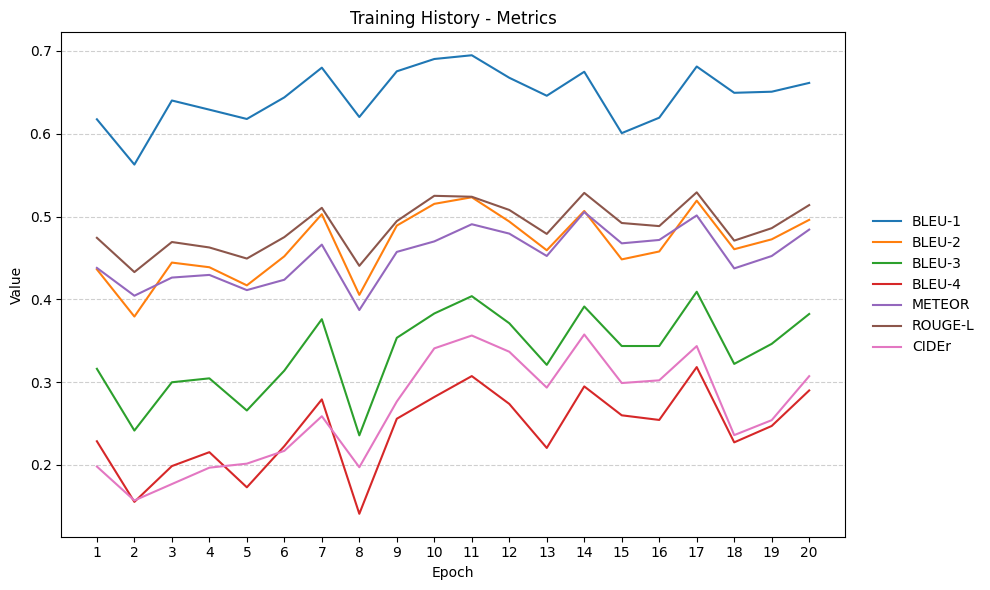

In [27]:
plot_history(hist, excluded_keys=("train_loss", "val_loss"), title="Training History - Metrics")

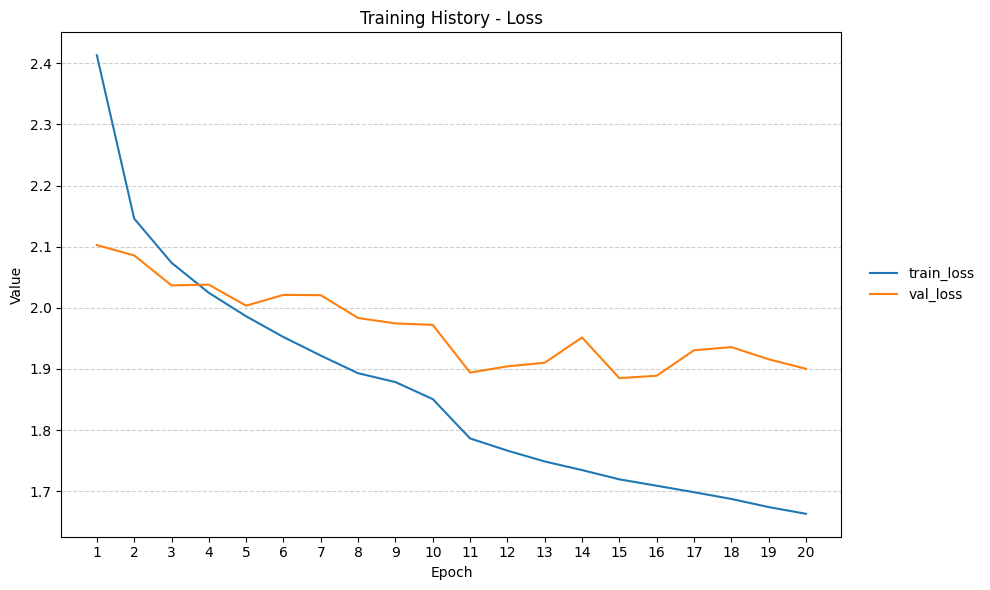

In [28]:
plot_history(hist, excluded_keys=("BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr"),
             title="Training History - Loss")